# Custom CNN for Surface Defect Classification (Teaching Notebook)

**Format:** Project-based, intuition-first, code-supported  
**Goal:** Build a *working* surface defect classifier using a custom CNN, then evaluate it like an inspection engineer.

---

## How to use this notebook
- Read the short teaching notes (Markdown)
- Run the small code blocks (core steps only)

> Tips: long topics are linked as “Further reading” so you can open those pages during class.


## 1. Industrial problem context

In manufacturing inspection, defect appearance can vary because of:
- illumination changes
- surface texture differences
- part orientation and camera angle
- small defect size / low contrast

**Why CNN here?**  
Rule-based features (thresholds, contours, hand-crafted texture) can work, but often require re-tuning when conditions change.  
A CNN can learn features directly from data and generalize better when variation is unavoidable.


## 2. Dataset overview (NEU-DET)

NEU-DET contains **6 classes** of steel surface defects.

What makes this dataset challenging:
- background intensity varies across images
- some classes have high texture diversity
- some defects look similar at small scale

**Example Images**


In [4]:
import os
import cv2
import matplotlib.pyplot as plt


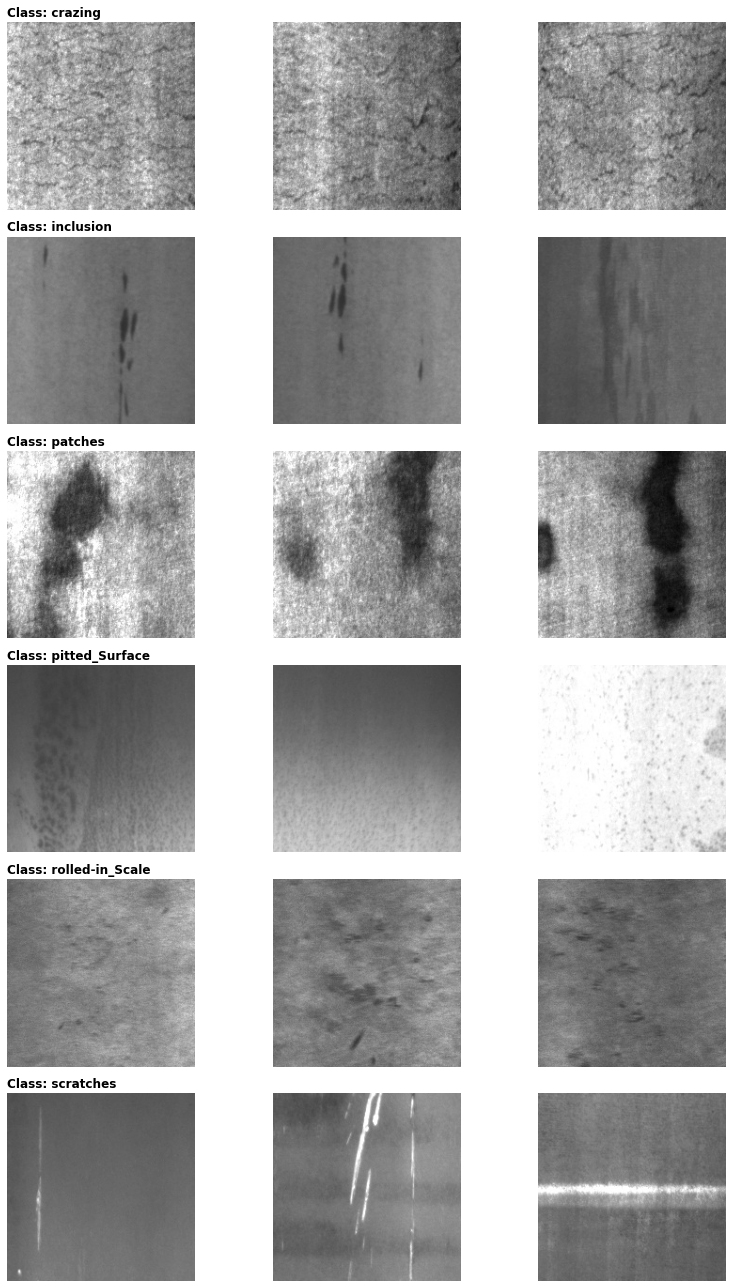

In [5]:
def show_neu_samples(base_path, num_samples=3):
    # รายชื่อคลาสทั้ง 6 ของ NEU
    classes = ['crazing', 'inclusion', 'patches', 'pitted_Surface', 'rolled-in_Scale', 'scratches']
    
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(12, 18))
    
    for i, cls in enumerate(classes):
        # สร้าง path ไปยังโฟลเดอร์ของแต่ละคลาส (ตรวจสอบโครงสร้างโฟลเดอร์หลัง unzip อีกครั้ง)
        cls_path = os.path.join(base_path, 'NEU-DET-A/train', cls) 
        # หมายเหตุ: หากโครงสร้างต่างออกไป ให้ปรับ path ตามความจริง
        
        # ดึงรายชื่อไฟล์ภาพมา num_samples ไฟล์
        img_names = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png'))][:num_samples]
        
        for j, img_name in enumerate(img_names):
            img_ptr = cv2.imread(os.path.join(cls_path, img_name))
            img_rgb = cv2.cvtColor(img_ptr, cv2.COLOR_BGR2RGB)
            
            axes[i, j].imshow(img_rgb)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(f"Class: {cls}", fontsize=12, loc='left', fontweight='bold')

    plt.tight_layout()
    plt.show()

# เรียกใช้งานฟังก์ชัน 
show_neu_samples('.')

## 3. Pipeline overview

```
Images → Preprocess/augmentation → CNN → Train → Evaluate → Confusion Matrix & Report → Error analysis
```

Key engineering rule:
- **Validation** guides model development (during training)
- **Test** is for the final “unseen” performance check

## 4. Imports and configuration

We keep the configuration (image size, batch size, paths) at the top for easy reuse.


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration Parameters
IMG_SIZE = (200, 200) # Standard size for NEU images
BATCH_SIZE = 32       # Number of images processed at once

#Define paths
train_path = './NEU-DET-A/train'
test_path = './NEU-DET-A/test'

## 5. Data loading and augmentation

**Data Augmentation** is a technique to increase a number of trainging images. It creates new, slightly modified versions of existing images in the dataset.

Its a critical technique used in training convolutional neural networks (CNNs), and it is primarily employed for two key reasons:

- Combating Overfitting

Neural networks, especially deep CNNs, have a vast number of parameters and require large amounts of data to train effectively. When the training dataset is small, the model tends to memorize the specifics of the training examples rather than learning generalizable features. This is known as overfitting.

- Improving model robusness

The core benefit of data augmentation is that it increases the robustness of the model. By training on images that have undergone slight shifts, rotations, flips, or have had noise added, the network learns to recognize objects even when they are presented in different orientations or under different lighting conditions.


!!! Apply augmentation to **training only**. Keep validation and test clean.


Tools: Tools like the Keras ImageDataGenerator class are specifically designed to perform these transformations in real-time during the training process.

Further reading:
- Keras `ImageDataGenerator`: https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration Parameters
IMG_SIZE = (200, 200) # Standard size for NEU images
BATCH_SIZE = 32       # Number of images processed at once

#Define paths
train_path = './NEU-DET-A/train'
test_path = './NEU-DET-A/test'

In [8]:
# 1. Training Generator (With Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# --- LOADERS ---
# Training Set (100% of the train folder)
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# 2. Validation & Testing Generator (Clean - No Augmentation)
# We use validation_split here to divide the unseen folder into two
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.5) 

# Validation Set (50% of the test folder)
# Used by the model during training to check progress
val_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training', # First half
    shuffle=False
)

# Unseen Testing Set (The other 50% of the test folder)
# !!!! The model NEVER sees this during training
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation', # Second half
    shuffle=False # CRITICAL: For Confusion Matrix accuracy
)

Found 1260 images belonging to 6 classes.
Found 270 images belonging to 6 classes.
Found 270 images belonging to 6 classes.


**Check balance dataset condition**

In [9]:
# Verify data and Check a number of images in the dataset
from collections import Counter

counter = Counter(train_generator.classes)

print(counter.items()) # dict_items([(0, 1648), (1, 3614)])

dict_items([(0, 210), (1, 210), (2, 210), (3, 210), (4, 210), (5, 210)])


## 6. Model design : Custom CNN for Defect Classification

A Convolutional Neural Network (CNN) acts as a hierarchical feature extractor. Instead of manually defining what a "scratch" or "particle" looks like, the model learns these features through stacked layers:

    Initial Layers: Detect "low-level" primitives like edges, gradients, and local textures.

    Deep Layers: Combine those primitives to identify "high-level" defect-specific patterns (e.g., a specific contamination shape).

**Design Logic for Our Use Case**

    3×3 Convolutions: The industry standard for capturing local spatial patterns while keeping the parameter count low.

    Max Pooling: Reduces spatial dimensionality. This provides translation invariance, allowing the model to detect a defect even if it shifts slightly in the frame.

    Dropout (e.g., 0.2 – 0.5): Randomly deactivates neurons during training. This prevents the model from "memorizing" specific training images (overfitting) and ensures it generalizes to new production samples.

    Softmax/Sigmoid Output: Converts raw signals into a probability score (e.g., "98% probability of a surface scratch").
    

Further reading:
- `CNN Model`:https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks
-             https://medium.com/@ziraddingulumjanly/cnn-simplified-cda250af36fc
- `NN vs CNN`:https://www.freecodecamp.org/news/convolutional-neural-network-tutorial-for-beginners/
- `Conv2D`: https://keras.io/api/layers/convolution_layers/convolution2d/
-            https://www.tensorflow.org/tutorials/images/cnn

In [10]:
# Define custom CNN model
from tensorflow.keras import layers, models

# Define the CNN structure
model = models.Sequential([
    # First Convolutional Block: Learns low-level features like edges and lines
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    layers.MaxPooling2D((2, 2)), # Reduces spatial dimensions to speed up computation
    
    # Second Convolutional Block: Learns mid-level features like shapes and textures
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Third Convolutional Block: Learns high-level features specific to the defects
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Classification Head: Converts 2D features into 1D class predictions
    layers.Flatten(), 
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Regularization to prevent overfitting on factory data
    layers.Dense(6, activation='softmax') # Output layer for 6 defect categories
])


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


## 7. Compile and Train

**Compile Model**
After we define the model architecture, we need to compile model, to converts high-level, human-readable code into a low-level, efficient, and executable format tailored for specific hardware (CPU or GPU) 
   
**The Training Setup**

- Optimizer: Adam – An adaptive learning rate algorithm. Think of it as an "auto-tuning" version of Gradient Descent that adjusts the step size based on how noisy the gradient is.

- Loss Function: **Categorical Cross-Entropy** – Measures the "distance" between the model's predicted probability distribution and the actual label. It punishes high confidence in the wrong category.

- Metric: Accuracy – The percentage of correctly classified images. While intuitive, engineers should also monitor the loss curve to detect potential instability.

We must watch two specific metrics:

    Training Accuracy: How well the model "memorizes" the specific defects in our training set.
    Validation Accuracy: How well the model classifies new, unseen defect samples from a different production batch.

Red Flag: If Training Accuracy is 95% but Validation is only 70%, the model has overfit. It is likely memorizing lighting conditions or background noise rather than the actual defect features.

In [11]:
# Compile the model with Adam optimizer and Categorical Crossentropy loss
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display the model architecture table
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 198, 198, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 99, 99, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 97, 97, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 48, 48, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 46, 46, 128)       73856     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 23, 23, 128)       0         
_________________________________________________________________
flatten (Flatten)            (None, 67712)             0

**Training the model**
1 Epoch = The model has seen every single image in your training set exactly once.

In our case: 
We have 6 classes with 210 images each:

    Total Training Images: 6×210=1,260 images.

    Batch Size: 32 images.
    
One Epoch = 1,260 Images.
Steps per Epoch = 40 Steps  (1260/32 \sim 39.37)
So The  model will take 40 steps (iterations) to complete 1 epoch.


In [12]:
# Train the model
# Typically, 15-25 epochs are usually enough to see significant improvement
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30
)

Epoch 1/30
40/40 [==============================] - 30s 739ms/step - loss: 1.9460 - acc: 0.2048 - val_loss: 1.6378 - val_acc: 0.2852
Epoch 2/30
40/40 [==============================] - 28s 699ms/step - loss: 1.1453 - acc: 0.5349 - val_loss: 1.1206 - val_acc: 0.4889
Epoch 3/30
40/40 [==============================] - 28s 690ms/step - loss: 0.7270 - acc: 0.7357 - val_loss: 1.0555 - val_acc: 0.5630
Epoch 4/30
40/40 [==============================] - 27s 680ms/step - loss: 0.5522 - acc: 0.8119 - val_loss: 0.9313 - val_acc: 0.6667
Epoch 5/30
40/40 [==============================] - 27s 680ms/step - loss: 0.4614 - acc: 0.8540 - val_loss: 0.8923 - val_acc: 0.6667
Epoch 6/30
40/40 [==============================] - 28s 710ms/step - loss: 0.3135 - acc: 0.8921 - val_loss: 1.3598 - val_acc: 0.6037
Epoch 7/30
40/40 [==============================] - 27s 680ms/step - loss: 0.4075 - acc: 0.8659 - val_loss: 1.4266 - val_acc: 0.6296
Epoch 8/30
40/40 [==============================] - 27s 678ms/step - 

## 8. Training curves: convergence and robustness

To verify if the model is learning the right features, we analyze the relationship between Training and Validation curves.

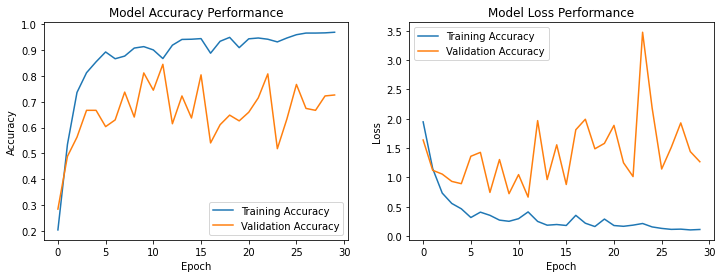

In [14]:
# Visualization: Plot training & validation accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['acc'], label='Training Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.title('Model Accuracy Performance')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()


# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Accuracy')
plt.plot(history.history['val_loss'], label='Validation Accuracy')
plt.title('Model Loss Performance')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

### Inspect training and validation curves:

**Ideal Fit**: Both curves decrease (Loss) or increase (Accuracy) steadily together.
**Overfitting**: training ↑ but validation ↓ or plateaus. The model is "memorizing" specific textures rather than learning general defect shapes.
**Underfitting**: both curves are low. The model fails to capture the dominant trend within the dataset
**High Variance (Noisy Curves)**: Large "swings" in validation accuracy often indicate the model is "jumping" over the optimal solution or the batch size is too small for the complex textures in the dataset.

**General Tips**: To fix instability and poor convergence in CNNs for any industrial imaging task, you need a strategy that addresses data quality, optimization, and architecture.

- Data-Centric Solutions : In many industrial cases, the model fails because it hasn't seen enough variety in the environment.

- Optimization Tuning: Learning Rate Schedulers,Batch Size Adjustment,Early Stopping

- Structural/Architectural Changes such as applying transfer learning


### Optional callbacks (Checkpoint / LR schedule/EarlyStopping / )

Callbacks can help, but on small/noisy validation sets they can also stop too early.

Learning Rate Schedulers: Instead of a fixed rate, use Decay or ReduceLROnPlateau. This "cools down" the learning process as the model gets closer to the goal.

Early Stopping: Set a monitor to stop training automatically if the validation loss doesn't improve for 5 or 10 epochs. This saves time and prevents the model from diverging.

If you use EarlyStopping, monitoring **val_accuracy** is often more stable than val_loss for this dataset.

Model Checkpointing: Since performance can peak early (e.g., at Epoch 9), we use ModelCheckpoint to auto-save the version with the highest validation accuracy, ensuring we don't deploy an "exhausted" version from Epoch 25.

In [15]:
# Train the model
# Typically, 15-25 epochs are usually enough to see significant improvement

from tensorflow.keras.callbacks import ModelCheckpoint

# Define the checkpoint callback
checkpoint = ModelCheckpoint(
    'best_defect_model.keras', # Name of the file to save
    monitor='val_acc',      # Watch validation accuracy
    save_best_only=True,         # Only overwrite if accuracy improves
    mode='max',                  # We want the maximum accuracy
    verbose=1                    # Prints a message when a new best is saved
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint] # The model now auto-saves the best version
)

Epoch 1/30
39/40 [============================>.] - ETA: 0s - loss: 0.1000 - acc: 0.9642
Epoch 00001: val_acc improved from -inf to 0.71852, saving model to best_defect_model.keras
40/40 [==============================] - 33s 824ms/step - loss: 0.0984 - acc: 0.9651 - val_loss: 1.7854 - val_acc: 0.7185
Epoch 2/30
39/40 [============================>.] - ETA: 0s - loss: 0.0979 - acc: 0.9715
Epoch 00002: val_acc did not improve from 0.71852
40/40 [==============================] - 30s 740ms/step - loss: 0.0986 - acc: 0.9714 - val_loss: 2.5642 - val_acc: 0.6963
Epoch 3/30
39/40 [============================>.] - ETA: 0s - loss: 0.1570 - acc: 0.9495
Epoch 00003: val_acc improved from 0.71852 to 0.74444, saving model to best_defect_model.keras
40/40 [==============================] - 30s 758ms/step - loss: 0.1600 - acc: 0.9492 - val_loss: 1.1780 - val_acc: 0.7444
Epoch 4/30
39/40 [============================>.] - ETA: 0s - loss: 0.1704 - acc: 0.9503
Epoch 00004: val_acc improved from 0.7444

Advanced Optimization: Learning Rate (LR) Decay

Sometimes, a static learning rate is too aggressive for the final stages of training. We use Exponential Decay to start with a high rate (for fast initial learning) and systematically reduce it using a LearningRateScheduler. This allows the model to make aggressive changes early on and fine-tuned adjustments as it nears the "best" weights.

In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint

# 1. Define a simple decay function
# In newer version of TF, we can call its function form the library
def lr_decay(epoch):
    initial_lr = 0.001
    drop = 0.9
    epochs_drop = 5.0
    # Every 5 epochs, multiply the LR by 0.9
    lr = initial_lr * (drop ** (epoch // epochs_drop))
    return lr

# 2. Define the checkpoint callback
checkpoint = ModelCheckpoint(
    'best_defect_model.keras', # Name of the file to save
    monitor='val_acc',      # Watch validation accuracy
    save_best_only=True,         # Only overwrite if accuracy improves
    mode='max',                  # We want the maximum accuracy
    verbose=1                    # Prints a message when a new best is saved
)

# 3. Import the Scheduler callback
from tensorflow.keras.callbacks import LearningRateScheduler # Use 'import keras' if using standalone

# 4. Create the callback instance
lr_scheduler = LearningRateScheduler(lr_decay, verbose=1)

# Compile with the scheduler instead of a fixed number
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Add it to your fit() call alongside your checkpoint
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[checkpoint, lr_scheduler] # Add it here
)


Epoch 00001: LearningRateScheduler reducing learning rate to 0.001.
Epoch 1/25
39/40 [============================>.] - ETA: 0s - loss: 0.2229 - acc: 0.9357
Epoch 00001: val_acc improved from -inf to 0.63333, saving model to best_defect_model.keras
40/40 [==============================] - 29s 729ms/step - loss: 0.2238 - acc: 0.9341 - val_loss: 2.8226 - val_acc: 0.6333

Epoch 00002: LearningRateScheduler reducing learning rate to 0.001.
Epoch 2/25
39/40 [============================>.] - ETA: 0s - loss: 0.1171 - acc: 0.9658
Epoch 00002: val_acc improved from 0.63333 to 0.64444, saving model to best_defect_model.keras
40/40 [==============================] - 28s 702ms/step - loss: 0.1201 - acc: 0.9651 - val_loss: 3.7975 - val_acc: 0.6444

Epoch 00003: LearningRateScheduler reducing learning rate to 0.001.
Epoch 3/25
39/40 [============================>.] - ETA: 0s - loss: 0.1288 - acc: 0.9625
Epoch 00003: val_acc improved from 0.64444 to 0.66667, saving model to best_defect_model.keras


39/40 [============================>.] - ETA: 0s - loss: 0.0305 - acc: 0.9910
Epoch 00024: val_acc did not improve from 0.86296
40/40 [==============================] - 28s 696ms/step - loss: 0.0310 - acc: 0.9905 - val_loss: 1.6013 - val_acc: 0.8111

Epoch 00025: LearningRateScheduler reducing learning rate to 0.0006561000000000001.
Epoch 25/25
39/40 [============================>.] - ETA: 0s - loss: 0.1058 - acc: 0.9805
Epoch 00025: val_acc improved from 0.86296 to 0.92963, saving model to best_defect_model.keras
40/40 [==============================] - 28s 690ms/step - loss: 0.1039 - acc: 0.9810 - val_loss: 0.8136 - val_acc: 0.9296


NameError: name 'history' is not defined

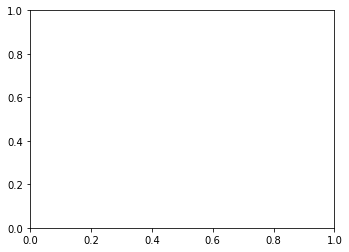

In [1]:
# Visualization: Plot training & validation accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['acc'], label='Training Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.title('Model Accuracy Performance')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()


# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Accuracy')
plt.plot(history.history['val_loss'], label='Validation Accuracy')
plt.title('Model Loss Performance')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

## 9. Evaluation on unseen test set

For inspection problems, evaluation is more than “accuracy”.
We use:
- confusion matrix (which classes confuse?)
- precision/recall/F1 (per-class reliability)

Further reading:
- Confusion matrix (scikit-learn): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- Classification report: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html


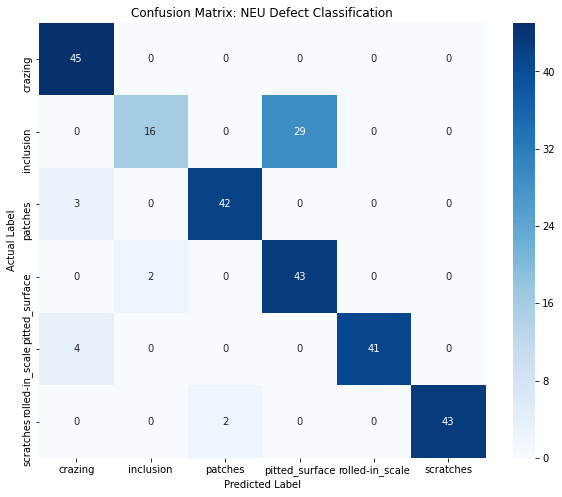


Classification Report (Precision, Recall, F1-Score):
                 precision    recall  f1-score   support

        crazing       0.87      1.00      0.93        45
      inclusion       0.89      0.36      0.51        45
        patches       0.95      0.93      0.94        45
 pitted_surface       0.60      0.96      0.74        45
rolled-in_scale       1.00      0.91      0.95        45
      scratches       1.00      0.96      0.98        45

       accuracy                           0.85       270
      macro avg       0.88      0.85      0.84       270
   weighted avg       0.88      0.85      0.84       270



In [18]:
# Testing the lost model with unseen
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generate predictions for the validation set
# We reset the generator to ensure it starts from the first image
test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1) # Get the index of the highest probability

# 2. Get the ground truth labels from the generator
y_true = test_generator.classes

# 3. Get the class names for labeling
target_names = list(test_generator.class_indices.keys())

# 4. Compute the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Visualize the Confusion Matrix using Seaborn for a professional look
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: NEU Defect Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Print Precision, Recall, and F1-Score for each class
print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred, target_names=target_names))

### Using the best model

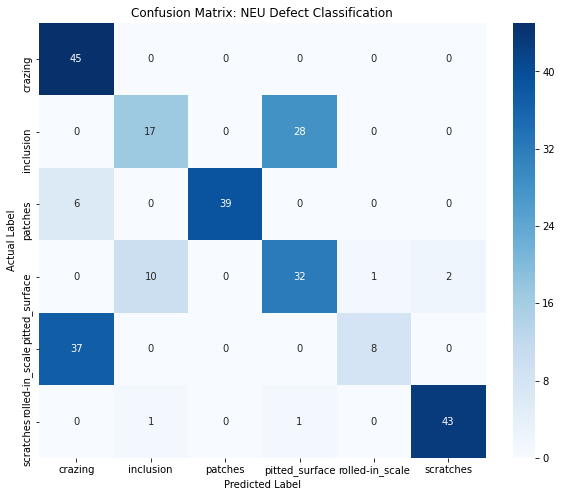


Classification Report (Precision, Recall, F1-Score):
                 precision    recall  f1-score   support

        crazing       0.51      1.00      0.68        45
      inclusion       0.61      0.38      0.47        45
        patches       1.00      0.87      0.93        45
 pitted_surface       0.52      0.71      0.60        45
rolled-in_scale       0.89      0.18      0.30        45
      scratches       0.96      0.96      0.96        45

       accuracy                           0.68       270
      macro avg       0.75      0.68      0.65       270
   weighted avg       0.75      0.68      0.65       270



In [15]:
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# CRITICAL STEP: Load the best version saved by the callback
model = load_model('best_defect_model.keras') 

# NOW run testing code
# We reset the generator to ensure it starts from the first image
test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1) # Get the index of the highest probability

# 2. Get the ground truth labels from the generator
y_true = test_generator.classes

# 3. Get the class names for labeling
target_names = list(test_generator.class_indices.keys())

# 4. Compute the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Visualize the Confusion Matrix using Seaborn for a professional look
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: NEU Defect Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Print Precision, Recall, and F1-Score for each class
print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred, target_names=target_names))

## 10. Error analysis

1. collect misclassified images
2. check lighting, contrast, and texture similarity
3. decide what to fix:
   - better data (more representative samples)
   - better preprocessing (contrast normalization)
   - model changes (slightly deeper, regularization)
   - or switch approach (transfer learning)

This is how inspection models improve in real projects.

## 11. Summary and takeaways

- Custom CNN is a strong baseline for NEU-DET
- Robustness often depends more on **data** than on “clever tricks”
- Use confusion matrix + report to guide improvements
- Keep a clean, unseen test set for honest performance
